Importing setup files

In [1]:
import pandas as pd
import torch
from sentence_transformers import SentenceTransformer, InputExample, losses
from torch.utils.data import DataLoader

C:\Users\USER\AppData\Local\Temp\ipykernel_2796\3056932391.py:3: DeprecationWarning: Importing from 'sentence_transformers.losses' is deprecated and will be removed in a future version. Please use 'sentence_transformers.sentence_transformer.losses' instead.
  from sentence_transformers import SentenceTransformer, InputExample, losses


Loading training triples

In [2]:
triples_df = pd.read_csv("phase7_training_triples.csv")

print("Training triples:", triples_df.shape)
triples_df.head()

Training triples: (8100, 6)


,query_id,anchor,positive,hard_negative,similarity_score,topic
0,0,How can blood donation centers collaborate wit...,Collaboration may involve implementing evidenc...,How can blood donation centers collaborate wit...,1.000000,Blood Type
1,0,How can blood donation centers collaborate wit...,Collaboration may involve implementing evidenc...,How can blood donation centers collaborate wit...,0.912461,Blood Type
2,0,How can blood donation centers collaborate wit...,Collaboration may involve implementing evidenc...,How can blood donation centers collaborate wit...,0.908266,Blood Type
3,1,What strategies can be employed to address the...,Strategies to address stigma and discriminatio...,What strategies can be employed to address the...,1.000000,Other
4,1,What strategies can be employed to address the...,Strategies to address stigma and discriminatio...,What measures can be implemented to address th...,0.935312,Other


Converting triples into training examples

In [3]:
train_examples = [
    InputExample(
        texts=[row.anchor, row.positive, row.hard_negative]
    )
    for row in triples_df.itertuples()
]

print("Training examples created:", len(train_examples))

Training examples created: 8100


Loading base MPNet model

In [4]:
model = SentenceTransformer("all-mpnet-base-v2")

print("Base MPNet loaded successfully.")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Base MPNet loaded successfully.


Creating dataloader

In [5]:
train_dataloader = DataLoader(
    train_examples,
    shuffle=True,
    batch_size=8
)

Defining TripletLoss

In [6]:
train_loss = losses.TripletLoss(model=model)

Start fine-tuning

In [7]:
model.fit(    
    train_objectives=[(train_dataloader, train_loss)],
    epochs=1,
    warmup_steps=100,
    show_progress_bar=True
)

Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

c:\Users\USER\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss
500,4.802645
1000,4.677207


Saving fine-tuned model

In [8]:
model.save("mpnet_donor_finetuned")

print("Fine-tuned MPNet saved successfully.")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Fine-tuned MPNet saved successfully.


Reloading model for evaluation

In [9]:
from sentence_transformers import SentenceTransformer

finetuned_model = SentenceTransformer("mpnet_donor_finetuned")

print("Fine-tuned model loaded.")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Fine-tuned model loaded.


## Validation Evaluation of Fine-Tuned MPNet

Load train and validation datasets

In [10]:
import pandas as pd
from sentence_transformers import SentenceTransformer, util
import matplotlib.pyplot as plt
import seaborn as sns

train_df = pd.read_csv("train.csv")
validation_df = pd.read_csv("validation.csv")

print("Train shape:", train_df.shape)
print("Validation shape:", validation_df.shape)

Train shape: (2700, 2)
Validation shape: (338, 2)


Prepare training and validation question-answer lists

In [11]:
train_questions = train_df["Question"].tolist()
train_answers = train_df["Answer"].tolist()

validation_questions = validation_df["Question"].tolist()
validation_answers = validation_df["Answer"].tolist()

print("Training questions:", len(train_questions))
print("Validation questions:", len(validation_questions))

Training questions: 2700
Validation questions: 338


Load the fine-tuned model

In [12]:
finetuned_model = SentenceTransformer("mpnet_donor_finetuned")

print("Fine-tuned MPNet loaded successfully.")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Fine-tuned MPNet loaded successfully.


Encode all training questions using the fine-tuned model

In [13]:
finetuned_train_embeddings = finetuned_model.encode(
    train_questions,
    convert_to_tensor=True,
    show_progress_bar=True
)

print("Fine-tuned training embeddings created.")
print("Embedding shape:", finetuned_train_embeddings.shape)

Batches:   0%|          | 0/85 [00:00<?, ?it/s]

Fine-tuned training embeddings created.
Embedding shape: torch.Size([2700, 768])


Define retrieval function for the fine-tuned model

In [14]:
def retrieve_answer_finetuned(user_query, questions, answers, embeddings, model):
    query_embedding = model.encode(user_query, convert_to_tensor=True)
    
    similarities = util.cos_sim(query_embedding, embeddings)[0]
    best_match_index = similarities.argmax().item()
    best_score = similarities[best_match_index].item()
    
    matched_question = questions[best_match_index]
    retrieved_answer = answers[best_match_index]
    
    return {
        "user_query": user_query,
        "matched_question": matched_question,
        "retrieved_answer": retrieved_answer,
        "similarity_score": best_score
    }

Run validation retrieval using the fine-tuned model

In [15]:
finetuned_results = []

for true_question, true_answer in zip(validation_questions, validation_answers):
    output = retrieve_answer_finetuned(
        true_question,
        train_questions,
        train_answers,
        finetuned_train_embeddings,
        finetuned_model
    )
    
    finetuned_results.append({
        "validation_question": true_question,
        "expected_answer": true_answer,
        "matched_question": output["matched_question"],
        "retrieved_answer": output["retrieved_answer"],
        "similarity_score": output["similarity_score"]
    })

finetuned_results_df = pd.DataFrame(finetuned_results)

print("Fine-tuned validation retrieval completed.")
finetuned_results_df.head()

Fine-tuned validation retrieval completed.


,validation_question,expected_answer,matched_question,retrieved_answer,similarity_score
0,What impact do intergenerational donation even...,"Intergenerational donation events, such as fam...",Question 51 How can community-based blood dona...,Hosting blood donation events in familiar and ...,0.982971
1,How do blood drive hosts collaborate with acad...,Blood drive hosts collaborate with academic in...,How do blood drive hosts engage with local gov...,Blood drive hosts engage with local government...,0.997817
2,What factors contribute to disparities in bloo...,Disparities in blood donation rates among diff...,What factors contribute to disparities in bloo...,Disparities in blood donation rates among raci...,0.919082
3,What role can celebrity endorsements and partn...,Celebrity endorsements and influencer partners...,What role can celebrity endorsements and influ...,Celebrity endorsements and influencer partners...,0.809935
4,How does blood donation support families of pa...,Blood donation supports families of patients b...,How can donating blood promote intergeneration...,Blood donation can encourage families to parti...,0.823986


Similarity score summary

In [16]:
print("Fine-tuned Validation Similarity Score Summary:")
print(finetuned_results_df["similarity_score"].describe())

Fine-tuned Validation Similarity Score Summary:
count    338.000000
mean       0.932125
std        0.124380
min        0.306821
25%        0.932165
50%        0.992031
75%        0.999146
max        0.999951
Name: similarity_score, dtype: float64


Compute fine-tuned semantic retrieval accuracy

In [17]:
finetuned_accuracy_085 = (finetuned_results_df["similarity_score"] >= 0.85).mean() * 100
finetuned_accuracy_090 = (finetuned_results_df["similarity_score"] >= 0.90).mean() * 100

print("Fine-tuned MPNet Semantic Retrieval Accuracy (>= 0.85):", round(finetuned_accuracy_085, 2), "%")
print("Fine-tuned MPNet Strict Semantic Retrieval Accuracy (>= 0.90):", round(finetuned_accuracy_090, 2), "%")

Fine-tuned MPNet Semantic Retrieval Accuracy (>= 0.85): 83.14 %
Fine-tuned MPNet Strict Semantic Retrieval Accuracy (>= 0.90): 77.81 %


Compare fine-tuned MPNet with baseline MPNet

In [18]:
comparison_finetuned_df = pd.DataFrame({
    "Metric": [
        "Semantic Accuracy >= 0.85",
        "Strict Semantic Accuracy >= 0.90"
    ],
    "Baseline MPNet": [
        83.73,
        62.72
    ],
    "Fine-Tuned MPNet": [
        round(finetuned_accuracy_085, 2),
        round(finetuned_accuracy_090, 2)
    ]
})

comparison_finetuned_df["Improvement"] = (
    comparison_finetuned_df["Fine-Tuned MPNet"] - comparison_finetuned_df["Baseline MPNet"]
)

comparison_finetuned_df

,Metric,Baseline MPNet,Fine-Tuned MPNet,Improvement
0,Semantic Accuracy >= 0.85,83.73,83.14,-0.59
1,Strict Semantic Accuracy >= 0.90,62.72,77.81,15.09


View best validation cases

In [19]:
best_finetuned_cases = finetuned_results_df.sort_values("similarity_score", ascending=False).head(10)

best_finetuned_cases[[
    "validation_question",
    "matched_question",
    "retrieved_answer",
    "similarity_score"
]]

,validation_question,matched_question,retrieved_answer,similarity_score
203,How do blood donation organizations collaborat...,How do blood donation organizations collaborat...,Blood donation organizations collaborate with ...,0.999951
224,What considerations should blood donation cent...,What considerations should blood donation cent...,Blood donation centers should consider factors...,0.999944
58,How can blood donation centers collaborate wit...,How can blood donation centers collaborate wit...,Collaboration with local media outlets can inv...,0.999943
163,What strategies can blood centers employ to pr...,What strategies can blood centers employ to pr...,Blood centers can employ strategies such as ta...,0.999942
45,How can blood donation centers effectively man...,How can blood donation centers effectively man...,Centers can manage expectations by providing a...,0.999941
157,How do blood donation centers ensure the safet...,How do blood donation centers ensure the safet...,Blood donation centers ensure the safety and q...,0.999928
111,How can blood donation centers leverage social...,How do blood donation centers leverage social ...,Blood donation centers collaborate with social...,0.999925
208,How can blood donation centers personalize app...,How can blood donation centers personalize app...,Blood donation centers can personalize appoint...,0.999923
89,How do blood donation centers ensure the ethic...,How do blood donation centers ensure the ethic...,Blood donation centers ensure the ethical recr...,0.999917
305,How can blood donation centers leverage data a...,How do blood donation centers leverage data an...,Blood donation centers analyze historical dona...,0.999893


View weakest validation cases

In [20]:
worst_finetuned_cases = finetuned_results_df.sort_values("similarity_score", ascending=True).head(20)

worst_finetuned_cases[[
    "validation_question",
    "matched_question",
    "retrieved_answer",
    "similarity_score"
]]

,validation_question,matched_question,retrieved_answer,similarity_score
131,How can individuals benefit from quitting smok...,What is the timing of withdrawal for individua...,The approved guidelines define the timing of w...,0.306821
86,How can donating blood inspire acts of kindness?,How do perceptions of donation as a means of e...,Perceptions of donation as a means of expressi...,0.387010
79,How can individuals benefit from consuming mor...,What is the current reliance status on emergen...,"There is no reliance; instead, the response is...",0.393578
18,How can donating blood create lasting positive...,How do past experiences with blood donation im...,"Past experiences with blood donation, whether ...",0.429852
44,How can perceptions of blood donation impact d...,How do public perceptions and media portrayals...,Public perceptions and media portrayals of blo...,0.437752
28,What role does community mobilization play in ...,How does the community-based blood donation pr...,The community-based blood donation program aim...,0.464856
12,What role do donor education and pre-donation ...,What role does donor education and counseling ...,Education and counseling can increase donor aw...,0.497248
81,How can appointment scheduling systems be opti...,How can appointment scheduling systems incorpo...,Appointment scheduling systems can incorporate...,0.511124
25,How can automated blood collection contribute ...,How can automated blood collection contribute ...,Automated blood collection contributes to a mo...,0.547537
219,What factors contribute to demographic dispari...,What factors contribute to disparities in bloo...,Disparities in blood donation rates among raci...,0.571478


Visualize similarity score distribution

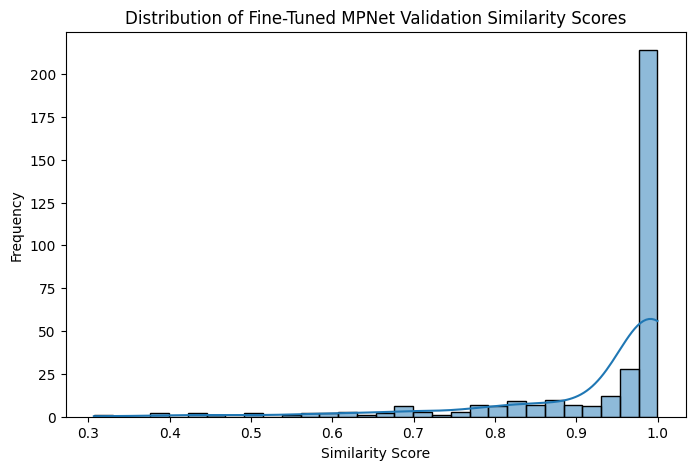

In [21]:
plt.figure(figsize=(8, 5))
sns.histplot(finetuned_results_df["similarity_score"], bins=30, kde=True)
plt.title("Distribution of Fine-Tuned MPNet Validation Similarity Scores")
plt.xlabel("Similarity Score")
plt.ylabel("Frequency")
plt.show()

Save Phase 9 outputs

In [22]:
finetuned_results_df.to_csv("phase9_validation_results_finetuned_mpnet.csv", index=False)
best_finetuned_cases.to_csv("phase9_best_validation_cases_finetuned_mpnet.csv", index=False)
worst_finetuned_cases.to_csv("phase9_worst_validation_cases_finetuned_mpnet.csv", index=False)
comparison_finetuned_df.to_csv("phase9_baseline_vs_finetuned_comparison.csv", index=False)

print("Saved Phase 9 validation outputs.")

Saved Phase 9 validation outputs.


Create Phase 9 summary table

In [23]:
phase9_summary = {
    "Validation samples": len(finetuned_results_df),
    "Fine-Tuned Semantic Accuracy (>= 0.85)": round(finetuned_accuracy_085, 2),
    "Fine-Tuned Strict Accuracy (>= 0.90)": round(finetuned_accuracy_090, 2),
    "Average similarity score": round(finetuned_results_df["similarity_score"].mean(), 4),
    "Minimum similarity score": round(finetuned_results_df["similarity_score"].min(), 4),
    "Maximum similarity score": round(finetuned_results_df["similarity_score"].max(), 4)
}

phase9_summary_df = pd.DataFrame(list(phase9_summary.items()), columns=["Metric", "Value"])
phase9_summary_df

,Metric,Value
0,Validation samples,338.0000
1,Fine-Tuned Semantic Accuracy (>= 0.85),83.1400
2,Fine-Tuned Strict Accuracy (>= 0.90),77.8100
3,Average similarity score,0.9321
4,Minimum similarity score,0.3068
5,Maximum similarity score,1.0000


## Test-Set Evaluation of Fine-Tuned MPNet

Load the test dataset

In [24]:
test_df = pd.read_csv("test.csv")

print("Test shape:", test_df.shape)
test_df.head()

Test shape: (338, 2)


,Question,Answer
0,How can individuals benefit from increasing th...,Vitamin K supports proper blood clotting and b...
1,How do blood drive hosts engage with religious...,Blood drive hosts collaborate with religious a...
2,What measures can be implemented to ensure the...,Measures may include developing ethical guidel...
3,What role do donor advocacy groups and organiz...,Donor advocacy groups and organizations can su...
4,What factors contribute to the usage intention...,Factors contributing to the usage intentions o...


Prepare test question-answer lists

In [25]:
test_questions = test_df["Question"].tolist()
test_answers = test_df["Answer"].tolist()

print("Number of test questions:", len(test_questions))

Number of test questions: 338


Encode all training questions using the fine-tuned model

In [26]:
finetuned_train_embeddings = finetuned_model.encode(
    train_questions,
    convert_to_tensor=True,
    show_progress_bar=True
)

print("Fine-tuned training embeddings for test evaluation created.")
print("Embedding shape:", finetuned_train_embeddings.shape)

Batches:   0%|          | 0/85 [00:00<?, ?it/s]

Fine-tuned training embeddings for test evaluation created.
Embedding shape: torch.Size([2700, 768])


Run retrieval on the full test set

In [27]:
finetuned_test_results = []

for true_question, true_answer in zip(test_questions, test_answers):
    output = retrieve_answer_finetuned(
        true_question,
        train_questions,
        train_answers,
        finetuned_train_embeddings,
        finetuned_model
    )
    
    finetuned_test_results.append({
        "test_question": true_question,
        "expected_answer": true_answer,
        "matched_question": output["matched_question"],
        "retrieved_answer": output["retrieved_answer"],
        "similarity_score": output["similarity_score"]
    })

finetuned_test_results_df = pd.DataFrame(finetuned_test_results)

print("Fine-tuned MPNet test retrieval completed.")
finetuned_test_results_df.head()

Fine-tuned MPNet test retrieval completed.


,test_question,expected_answer,matched_question,retrieved_answer,similarity_score
0,How can individuals benefit from increasing th...,Vitamin K supports proper blood clotting and b...,How can individuals benefit from consuming mor...,"Potassium-rich foods such as bananas, potatoes...",0.580653
1,How do blood drive hosts engage with religious...,Blood drive hosts collaborate with religious a...,How do blood drive hosts engage faith-based or...,Blood drive hosts engage faith-based organizat...,0.997511
2,What measures can be implemented to ensure the...,Measures may include developing ethical guidel...,What measures can be implemented to address sh...,Blood donation centers diversify their supply ...,0.986218
3,What role do donor advocacy groups and organiz...,Donor advocacy groups and organizations can su...,"What role do blood donor advocacy groups, pati...","Blood donor advocacy groups, patient support o...",0.988398
4,What factors contribute to the usage intention...,Factors contributing to the usage intentions o...,What factors influence an individual's decisio...,Factors influencing blood donation decisions m...,0.689388


Similarity score summary

In [28]:
print("Fine-tuned MPNet Test Similarity Score Summary:")
print(finetuned_test_results_df["similarity_score"].describe())

Fine-tuned MPNet Test Similarity Score Summary:
count    338.000000
mean       0.910379
std        0.157521
min        0.248129
25%        0.902573
50%        0.989907
75%        0.999096
max        0.999940
Name: similarity_score, dtype: float64


Compute test semantic retrieval accuracy

In [29]:
finetuned_test_accuracy_085 = (finetuned_test_results_df["similarity_score"] >= 0.85).mean() * 100
finetuned_test_accuracy_090 = (finetuned_test_results_df["similarity_score"] >= 0.90).mean() * 100

print("Fine-tuned MPNet Test Semantic Retrieval Accuracy (>= 0.85):", round(finetuned_test_accuracy_085, 2), "%")
print("Fine-tuned MPNet Test Strict Semantic Retrieval Accuracy (>= 0.90):", round(finetuned_test_accuracy_090, 2), "%")

Fine-tuned MPNet Test Semantic Retrieval Accuracy (>= 0.85): 79.59 %
Fine-tuned MPNet Test Strict Semantic Retrieval Accuracy (>= 0.90): 75.15 %


Compare fine-tuned MPNet with pretrained MPNet on test set

In [30]:
comparison_finetuned_test_df = pd.DataFrame({
    "Metric": [
        "Semantic Accuracy >= 0.85",
        "Strict Semantic Accuracy >= 0.90"
    ],
    "Pretrained MPNet Test": [
        85.50,
        59.47
    ],
    "Fine-Tuned MPNet Test": [
        round(finetuned_test_accuracy_085, 2),
        round(finetuned_test_accuracy_090, 2)
    ]
})

comparison_finetuned_test_df["Improvement"] = (
    comparison_finetuned_test_df["Fine-Tuned MPNet Test"] - comparison_finetuned_test_df["Pretrained MPNet Test"]
)

comparison_finetuned_test_df

,Metric,Pretrained MPNet Test,Fine-Tuned MPNet Test,Improvement
0,Semantic Accuracy >= 0.85,85.50,79.59,-5.91
1,Strict Semantic Accuracy >= 0.90,59.47,75.15,15.68


Compare fine-tuned validation vs test performance

In [31]:
comparison_finetuned_generalization_df = pd.DataFrame({
    "Metric": [
        "Semantic Accuracy >= 0.85",
        "Strict Semantic Accuracy >= 0.90"
    ],
    "Fine-Tuned Validation": [
        83.14,
        77.81
    ],
    "Fine-Tuned Test": [
        round(finetuned_test_accuracy_085, 2),
        round(finetuned_test_accuracy_090, 2)
    ]
})

comparison_finetuned_generalization_df["Difference"] = (
    comparison_finetuned_generalization_df["Fine-Tuned Test"] - comparison_finetuned_generalization_df["Fine-Tuned Validation"]
)

comparison_finetuned_generalization_df

,Metric,Fine-Tuned Validation,Fine-Tuned Test,Difference
0,Semantic Accuracy >= 0.85,83.14,79.59,-3.55
1,Strict Semantic Accuracy >= 0.90,77.81,75.15,-2.66


View best test cases

In [32]:
best_finetuned_test_cases = finetuned_test_results_df.sort_values("similarity_score", ascending=False).head(10)

best_finetuned_test_cases[[
    "test_question",
    "matched_question",
    "retrieved_answer",
    "similarity_score"
]]

,test_question,matched_question,retrieved_answer,similarity_score
19,How do blood donation centers ensure the safet...,How do blood donation centers ensure the safet...,Blood donation centers adhere to strict protoc...,0.999940
177,What strategies can blood donation centers use...,What strategies can blood donation centers use...,Blood donation centers can use strategies to e...,0.999927
129,How do blood donation centers ensure the confi...,How do blood donation centers ensure the confi...,Blood donation centers ensure the confidential...,0.999925
256,How do blood donation centers leverage data an...,How do blood donation centers leverage donor d...,"Blood donation centers collect, analyze, and l...",0.999914
216,How do blood donation centers ensure the safet...,How do blood donation centers ensure the safet...,Blood donation centers ensure the safety and q...,0.999907
118,How can blood donation centers collaborate wit...,How do blood donation centers collaborate with...,Blood donation centers partner with transporta...,0.999905
311,How can blood donation centers collaborate wit...,How do blood donation centers engage with scho...,Blood donation centers engage with schools and...,0.999867
208,How do blood donation centers collaborate with...,How can blood donation centers collaborate wit...,Blood donation centers can collaborate with lo...,0.999867
16,What strategies can blood donation centers use...,What strategies can blood donation centers use...,Blood donation centers can encourage donors to...,0.999861
205,What strategies can blood donation centers emp...,What strategies can blood donation centers emp...,Blood donation centers can employ strategies s...,0.999854


View weakest test cases

In [33]:
worst_finetuned_test_cases = finetuned_test_results_df.sort_values("similarity_score", ascending=True).head(20)

worst_finetuned_test_cases[[
    "test_question",
    "matched_question",
    "retrieved_answer",
    "similarity_score"
]]

,test_question,matched_question,retrieved_answer,similarity_score
39,How can individuals benefit from consuming mor...,What role do medical professionals play in sup...,Medical professionals play a critical role in ...,0.248129
337,How can individuals benefit from consuming mor...,How can individuals benefit from consuming mor...,"Dark leafy greens provide iron, folate, and ot...",0.330594
52,How can donating blood help reduce the risk of...,How can blood donation contribute to reducing ...,Blood donation can contribute to reducing the ...,0.349769
42,How can donating blood contribute to a culture...,How does donating blood promote greater empathy?,Donating blood promotes greater empathy by con...,0.350304
322,How does blood donation help protect against c...,How can donating blood impact individuals with...,Individuals with learning disabilities might b...,0.364769
249,What is the significance of maintaining approp...,What are the implications of blood shortages f...,Blood shortages can result in delays or cancel...,0.374629
298,How can individuals benefit from increasing th...,How does the implementation of donor incentive...,The implementation of donor incentives or rewa...,0.387214
325,How can individuals benefit from reducing thei...,How can individuals benefit from avoiding proc...,Avoiding processed snacks helps maintain stabl...,0.391563
48,What role does donor retention play in maintai...,What are the potential consequences of relying...,Relying on repeat donors versus recruiting new...,0.416683
310,What are the specific requirements for the phy...,What is the procedure for donors to undergo a ...,"According to the approved guidelines, donors a...",0.421948


Visualize similarity distribution

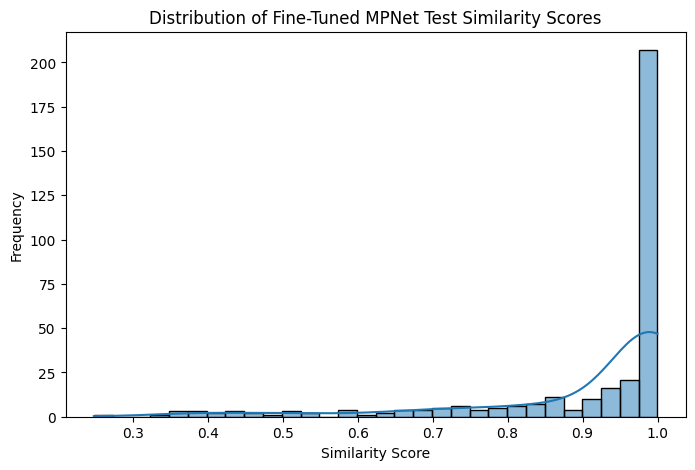

In [34]:
plt.figure(figsize=(8, 5))
sns.histplot(finetuned_test_results_df["similarity_score"], bins=30, kde=True)
plt.title("Distribution of Fine-Tuned MPNet Test Similarity Scores")
plt.xlabel("Similarity Score")
plt.ylabel("Frequency")
plt.show()

Add confidence labels

In [35]:
def confidence_label(score):
    if score >= 0.90:
        return "Very High"
    elif score >= 0.85:
        return "High"
    elif score >= 0.75:
        return "Moderate"
    else:
        return "Low"

finetuned_test_results_df["confidence_level"] = finetuned_test_results_df["similarity_score"].apply(confidence_label)

print(finetuned_test_results_df["confidence_level"].value_counts())

confidence_level
Very High    254
Low           47
Moderate      22
High          15
Name: count, dtype: int64


Save Phase 10 outputs

In [36]:
finetuned_test_results_df.to_csv("phase10_test_results_finetuned_mpnet.csv", index=False)
best_finetuned_test_cases.to_csv("phase10_best_test_cases_finetuned_mpnet.csv", index=False)
worst_finetuned_test_cases.to_csv("phase10_worst_test_cases_finetuned_mpnet.csv", index=False)
comparison_finetuned_test_df.to_csv("phase10_pretrained_vs_finetuned_test_comparison.csv", index=False)
comparison_finetuned_generalization_df.to_csv("phase10_finetuned_validation_vs_test_comparison.csv", index=False)

print("Saved Phase 10 outputs.")

Saved Phase 10 outputs.


Create Phase 10 summary table

In [37]:
phase10_summary = {
    "Test samples": len(finetuned_test_results_df),
    "Fine-Tuned Test Accuracy (>= 0.85)": round(finetuned_test_accuracy_085, 2),
    "Fine-Tuned Test Accuracy (>= 0.90)": round(finetuned_test_accuracy_090, 2),
    "Average similarity score": round(finetuned_test_results_df["similarity_score"].mean(), 4),
    "Minimum similarity score": round(finetuned_test_results_df["similarity_score"].min(), 4),
    "Maximum similarity score": round(finetuned_test_results_df["similarity_score"].max(), 4)
}

phase10_summary_df = pd.DataFrame(list(phase10_summary.items()), columns=["Metric", "Value"])
phase10_summary_df

,Metric,Value
0,Test samples,338.0000
1,Fine-Tuned Test Accuracy (>= 0.85),79.5900
2,Fine-Tuned Test Accuracy (>= 0.90),75.1500
3,Average similarity score,0.9104
4,Minimum similarity score,0.2481
5,Maximum similarity score,0.9999


## Confidence Threshold Recalibration

Inspect current similarity distribution again

In [38]:
print("Fine-tuned Test Similarity Score Summary:")
print(finetuned_test_results_df["similarity_score"].describe())

Fine-tuned Test Similarity Score Summary:
count    338.000000
mean       0.910379
std        0.157521
min        0.248129
25%        0.902573
50%        0.989907
75%        0.999096
max        0.999940
Name: similarity_score, dtype: float64


Compute useful percentiles

In [39]:
percentiles = finetuned_test_results_df["similarity_score"].quantile([0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
print(percentiles)

0.10    0.692174
0.25    0.902573
0.50    0.989907
0.75    0.999096
0.90    0.999706
0.95    0.999808
0.99    0.999912
Name: similarity_score, dtype: float64


Visualize the fine-tuned similarity distribution

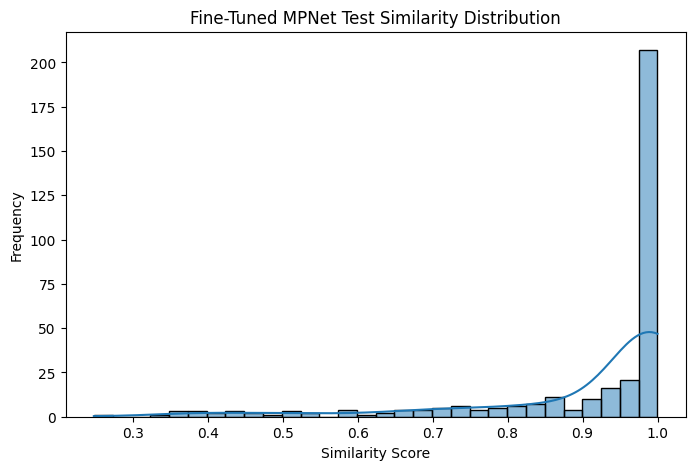

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(finetuned_test_results_df["similarity_score"], bins=30, kde=True)
plt.title("Fine-Tuned MPNet Test Similarity Distribution")
plt.xlabel("Similarity Score")
plt.ylabel("Frequency")
plt.show()

Define recalibrated confidence thresholds

In [41]:
def recalibrated_confidence_label(score):
    if score >= 0.95:
        return "Very High"
    elif score >= 0.90:
        return "High"
    elif score >= 0.80:
        return "Moderate"
    else:
        return "Low"

Apply recalibrated confidence labels

In [42]:
finetuned_test_results_df["recalibrated_confidence"] = (
    finetuned_test_results_df["similarity_score"].apply(recalibrated_confidence_label)
)

print(finetuned_test_results_df["recalibrated_confidence"].value_counts())

recalibrated_confidence
Very High    228
Low           56
Moderate      28
High          26
Name: count, dtype: int64


Visualize recalibrated confidence distribution

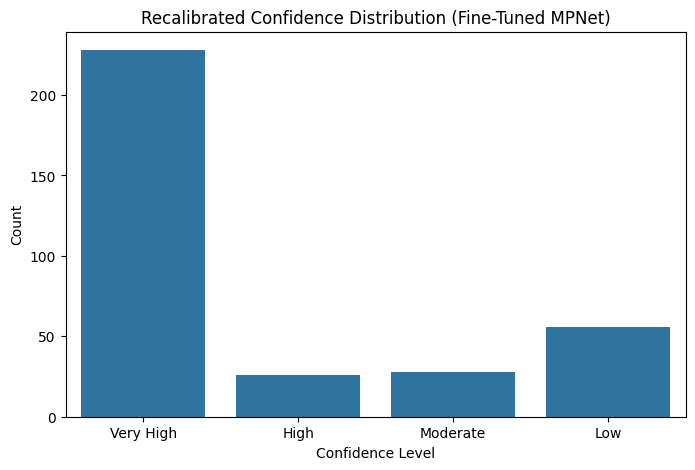

In [43]:
plt.figure(figsize=(8,5))
sns.countplot(
    data=finetuned_test_results_df,
    x="recalibrated_confidence",
    order=["Very High", "High", "Moderate", "Low"]
)
plt.title("Recalibrated Confidence Distribution (Fine-Tuned MPNet)")
plt.xlabel("Confidence Level")
plt.ylabel("Count")
plt.show()

Create recalibrated response logic

In [44]:
def generate_recalibrated_safe_response(user_query, questions, answers, embeddings, model, top_k=3):
    query_embedding = model.encode(user_query, convert_to_tensor=True)
    similarities = util.cos_sim(query_embedding, embeddings)[0]
    
    top_results = similarities.topk(k=top_k)
    top_indices = top_results.indices.tolist()
    top_scores = top_results.values.tolist()
    
    top_matches = []
    for idx, score in zip(top_indices, top_scores):
        top_matches.append({
            "matched_question": questions[idx],
            "retrieved_answer": answers[idx],
            "similarity_score": float(score)
        })
    
    best_match = top_matches[0]
    best_score = best_match["similarity_score"]
    confidence = recalibrated_confidence_label(best_score)
    
    if confidence == "Very High":
        final_response = best_match["retrieved_answer"]
        response_type = "Direct Answer"
        
    elif confidence == "High":
        final_response = "Based on similar donor guidance: " + best_match["retrieved_answer"]
        response_type = "Direct Answer with Reassurance"
        
    elif confidence == "Moderate":
        suggestion_text = "I found a related answer that may help:\n\n"
        suggestion_text += best_match["retrieved_answer"]
        suggestion_text += "\n\nYou may also mean one of these related questions:\n"
        
        for i, match in enumerate(top_matches, start=1):
            suggestion_text += f"{i}. {match['matched_question']}\n"
        
        final_response = suggestion_text
        response_type = "Answer with Top-3 Suggestions"
        
    else:
        final_response = (
            "I’m not fully certain about this question. "
            "Please rephrase it or consult a blood donation professional "
            "or your nearest donation center for accurate guidance."
        )
        response_type = "Fallback Response"
    
    return {
        "user_query": user_query,
        "best_matched_question": best_match["matched_question"],
        "similarity_score": best_score,
        "confidence_level": confidence,
        "response_type": response_type,
        "final_response": final_response,
        "top_matches": top_matches
    }

Test the recalibrated response logic

In [45]:
test_recalibrated_result = generate_recalibrated_safe_response(
    user_query="Can I donate blood if I have a cold?",
    questions=train_questions,
    answers=train_answers,
    embeddings=finetuned_train_embeddings,
    model=finetuned_model,
    top_k=3
)

print("User Query:", test_recalibrated_result["user_query"])
print("Best Matched Question:", test_recalibrated_result["best_matched_question"])
print("Similarity Score:", round(test_recalibrated_result["similarity_score"], 4))
print("Confidence Level:", test_recalibrated_result["confidence_level"])
print("Response Type:", test_recalibrated_result["response_type"])
print("\nFinal Response:\n")
print(test_recalibrated_result["final_response"])

User Query: Can I donate blood if I have a cold?
Best Matched Question: How can blood donation support individuals with chronic illnesses?
Similarity Score: 0.3088
Confidence Level: Low
Response Type: Fallback Response

Final Response:

I’m not fully certain about this question. Please rephrase it or consult a blood donation professional or your nearest donation center for accurate guidance.


Apply recalibrated logic to the full test set

In [46]:
phase11_test_results = []

for test_question in test_questions:
    result = generate_recalibrated_safe_response(
        user_query=test_question,
        questions=train_questions,
        answers=train_answers,
        embeddings=finetuned_train_embeddings,
        model=finetuned_model,
        top_k=3
    )
    
    phase11_test_results.append({
        "test_question": result["user_query"],
        "best_matched_question": result["best_matched_question"],
        "similarity_score": result["similarity_score"],
        "confidence_level": result["confidence_level"],
        "response_type": result["response_type"],
        "final_response": result["final_response"]
    })

phase11_test_results_df = pd.DataFrame(phase11_test_results)

print("Phase 11 recalibrated response generation completed.")
phase11_test_results_df.head()

Phase 11 recalibrated response generation completed.


,test_question,best_matched_question,similarity_score,confidence_level,response_type,final_response
0,How can individuals benefit from increasing th...,How can individuals benefit from consuming mor...,0.580653,Low,Fallback Response,I’m not fully certain about this question. Ple...
1,How do blood drive hosts engage with religious...,How do blood drive hosts engage faith-based or...,0.997511,Very High,Direct Answer,Blood drive hosts engage faith-based organizat...
2,What measures can be implemented to ensure the...,What measures can be implemented to address sh...,0.986218,Very High,Direct Answer,Blood donation centers diversify their supply ...
3,What role do donor advocacy groups and organiz...,"What role do blood donor advocacy groups, pati...",0.988398,Very High,Direct Answer,"Blood donor advocacy groups, patient support o..."
4,What factors contribute to the usage intention...,What factors influence an individual's decisio...,0.689388,Low,Fallback Response,I’m not fully certain about this question. Ple...


View recalibrated confidence counts

In [47]:
print("Recalibrated Confidence Distribution:")
print(phase11_test_results_df["confidence_level"].value_counts())

Recalibrated Confidence Distribution:
confidence_level
Very High    228
Low           56
Moderate      28
High          26
Name: count, dtype: int64


View recalibrated response-type counts

In [48]:
print("Recalibrated Response Type Distribution:")
print(phase11_test_results_df["response_type"].value_counts())

Recalibrated Response Type Distribution:
response_type
Direct Answer                     228
Fallback Response                  56
Answer with Top-3 Suggestions      28
Direct Answer with Reassurance     26
Name: count, dtype: int64


Inspect low-confidence cases

In [49]:
phase11_low_confidence_cases = phase11_test_results_df[
    phase11_test_results_df["confidence_level"] == "Low"
]

print("Number of recalibrated low-confidence cases:", len(phase11_low_confidence_cases))
phase11_low_confidence_cases.head(20)

Number of recalibrated low-confidence cases: 56


,test_question,best_matched_question,similarity_score,confidence_level,response_type,final_response
0,How can individuals benefit from increasing th...,How can individuals benefit from consuming mor...,0.580653,Low,Fallback Response,I’m not fully certain about this question. Ple...
4,What factors contribute to the usage intention...,What factors influence an individual's decisio...,0.689388,Low,Fallback Response,I’m not fully certain about this question. Ple...
8,How can donating blood promote greater trust i...,What role do medical professionals play in sup...,0.738449,Low,Fallback Response,I’m not fully certain about this question. Ple...
10,How do societal attitudes toward blood and bod...,How do cultural attitudes towards blood and he...,0.423999,Low,Fallback Response,I’m not fully certain about this question. Ple...
21,What are some potential motivators for individ...,What role do incentives play in encouraging pa...,0.442639,Low,Fallback Response,I’m not fully certain about this question. Ple...
31,Question 70 What cultural sensitivities should...,How can cultural sensitivity impact blood dona...,0.786144,Low,Fallback Response,I’m not fully certain about this question. Ple...
39,How can individuals benefit from consuming mor...,What role do medical professionals play in sup...,0.248129,Low,Fallback Response,I’m not fully certain about this question. Ple...
42,How can donating blood contribute to a culture...,How does donating blood promote greater empathy?,0.350304,Low,Fallback Response,I’m not fully certain about this question. Ple...
48,What role does donor retention play in maintai...,What are the potential consequences of relying...,0.416683,Low,Fallback Response,I’m not fully certain about this question. Ple...
52,How can donating blood help reduce the risk of...,How can blood donation contribute to reducing ...,0.349769,Low,Fallback Response,I’m not fully certain about this question. Ple...


Inspect moderate-confidence cases

In [50]:
phase11_moderate_cases = phase11_test_results_df[
    phase11_test_results_df["confidence_level"] == "Moderate"
]

print("Number of recalibrated moderate-confidence cases:", len(phase11_moderate_cases))
phase11_moderate_cases.head(20)

Number of recalibrated moderate-confidence cases: 28


,test_question,best_matched_question,similarity_score,confidence_level,response_type,final_response
7,How can targeted marketing campaigns be used t...,What are the benefits of implementing targeted...,0.861229,Moderate,Answer with Top-3 Suggestions,I found a related answer that may help:\n\nTar...
12,How can blood banks ensure ethical practices i...,How can blood banks adapt automated blood coll...,0.806541,Moderate,Answer with Top-3 Suggestions,I found a related answer that may help:\n\nBlo...
24,What steps are taken to address potential bias...,How do national guidelines ensure the standard...,0.852533,Moderate,Answer with Top-3 Suggestions,I found a related answer that may help:\n\nNat...
32,What role can celebrity endorsements and partn...,What role can celebrity endorsements and influ...,0.835222,Moderate,Answer with Top-3 Suggestions,I found a related answer that may help:\n\nCel...
44,How can individuals optimize their rest and re...,How can individuals balance work and rest peri...,0.861432,Moderate,Answer with Top-3 Suggestions,I found a related answer that may help:\n\nBal...
45,What role do philanthropic organizations and f...,What role can philanthropic foundations and ch...,0.825925,Moderate,Answer with Top-3 Suggestions,I found a related answer that may help:\n\nPhi...
77,How does the program address the unique needs ...,How do appointment scheduling systems accommod...,0.848137,Moderate,Answer with Top-3 Suggestions,I found a related answer that may help:\n\nApp...
82,Can individuals with a history of recent surge...,How can blood donation support patients underg...,0.842547,Moderate,Answer with Top-3 Suggestions,I found a related answer that may help:\n\nBlo...
88,What factors contribute to disparities in bloo...,Can individuals who have traveled to malaria-e...,0.863601,Moderate,Answer with Top-3 Suggestions,I found a related answer that may help:\n\nDon...
110,Question 85 How can the involvement of local c...,What role can local celebrities and influencer...,0.878929,Moderate,Answer with Top-3 Suggestions,I found a related answer that may help:\n\nLoc...


Save Phase 11 outputs

In [51]:
phase11_test_results_df.to_csv("phase11_recalibrated_test_results.csv", index=False)
phase11_low_confidence_cases.to_csv("phase11_low_confidence_cases.csv", index=False)
phase11_moderate_cases.to_csv("phase11_moderate_confidence_cases.csv", index=False)

print("Saved Phase 11 outputs.")

Saved Phase 11 outputs.


Create Phase 11 summary table

In [52]:
phase11_summary = {
    "Total test queries": len(phase11_test_results_df),
    "Very High confidence responses": (phase11_test_results_df["confidence_level"] == "Very High").sum(),
    "High confidence responses": (phase11_test_results_df["confidence_level"] == "High").sum(),
    "Moderate confidence responses": (phase11_test_results_df["confidence_level"] == "Moderate").sum(),
    "Low confidence responses": (phase11_test_results_df["confidence_level"] == "Low").sum()
}

phase11_summary_df = pd.DataFrame(list(phase11_summary.items()), columns=["Metric", "Value"])
phase11_summary_df

,Metric,Value
0,Total test queries,338
1,Very High confidence responses,228
2,High confidence responses,26
3,Moderate confidence responses,28
4,Low confidence responses,56


## Softer Threshold Adjustment

Define softer recalibrated thresholds

In [53]:
def softer_confidence_label(score):
    if score >= 0.93:
        return "Very High"
    elif score >= 0.88:
        return "High"
    elif score >= 0.78:
        return "Moderate"
    else:
        return "Low"

Apply softer confidence labels to test scores

In [54]:
finetuned_test_results_df["softer_confidence"] = (
    finetuned_test_results_df["similarity_score"].apply(softer_confidence_label)
)

print("Softer Confidence Distribution:")
print(finetuned_test_results_df["softer_confidence"].value_counts())

Softer Confidence Distribution:
softer_confidence
Very High    243
Low           51
Moderate      30
High          14
Name: count, dtype: int64


Visualize softer confidence distribution

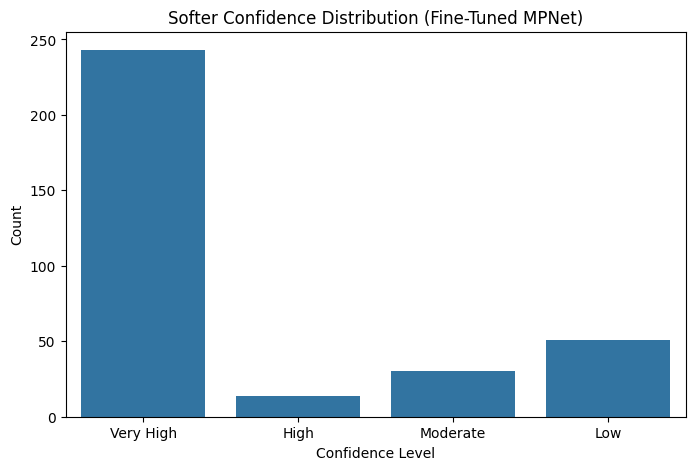

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.countplot(
    data=finetuned_test_results_df,
    x="softer_confidence",
    order=["Very High", "High", "Moderate", "Low"]
)
plt.title("Softer Confidence Distribution (Fine-Tuned MPNet)")
plt.xlabel("Confidence Level")
plt.ylabel("Count")
plt.show()

Create softer response logic

In [56]:
def generate_softer_safe_response(user_query, questions, answers, embeddings, model, top_k=3):
    query_embedding = model.encode(user_query, convert_to_tensor=True)
    similarities = util.cos_sim(query_embedding, embeddings)[0]
    
    top_results = similarities.topk(k=top_k)
    top_indices = top_results.indices.tolist()
    top_scores = top_results.values.tolist()
    
    top_matches = []
    for idx, score in zip(top_indices, top_scores):
        top_matches.append({
            "matched_question": questions[idx],
            "retrieved_answer": answers[idx],
            "similarity_score": float(score)
        })
    
    best_match = top_matches[0]
    best_score = best_match["similarity_score"]
    confidence = softer_confidence_label(best_score)
    
    if confidence == "Very High":
        final_response = best_match["retrieved_answer"]
        response_type = "Direct Answer"
        
    elif confidence == "High":
        final_response = "Based on similar donor guidance: " + best_match["retrieved_answer"]
        response_type = "Direct Answer with Reassurance"
        
    elif confidence == "Moderate":
        suggestion_text = "I found a related answer that may help:\n\n"
        suggestion_text += best_match["retrieved_answer"]
        suggestion_text += "\n\nYou may also mean one of these related questions:\n"
        
        for i, match in enumerate(top_matches, start=1):
            suggestion_text += f"{i}. {match['matched_question']}\n"
        
        final_response = suggestion_text
        response_type = "Answer with Top-3 Suggestions"
        
    else:
        final_response = (
            "I’m not fully certain about this question. "
            "Please rephrase it or consult a blood donation professional "
            "or your nearest donation center for accurate guidance."
        )
        response_type = "Fallback Response"
    
    return {
        "user_query": user_query,
        "best_matched_question": best_match["matched_question"],
        "similarity_score": best_score,
        "confidence_level": confidence,
        "response_type": response_type,
        "final_response": final_response,
        "top_matches": top_matches
    }

Test the softer policy on one question

In [57]:
soft_test_result = generate_softer_safe_response(
    user_query="Can I donate blood if I have a cold?",
    questions=train_questions,
    answers=train_answers,
    embeddings=finetuned_train_embeddings,
    model=finetuned_model,
    top_k=3
)

print("User Query:", soft_test_result["user_query"])
print("Best Matched Question:", soft_test_result["best_matched_question"])
print("Similarity Score:", round(soft_test_result["similarity_score"], 4))
print("Confidence Level:", soft_test_result["confidence_level"])
print("Response Type:", soft_test_result["response_type"])
print("\nFinal Response:\n")
print(soft_test_result["final_response"])

User Query: Can I donate blood if I have a cold?
Best Matched Question: How can blood donation support individuals with chronic illnesses?
Similarity Score: 0.3088
Confidence Level: Low
Response Type: Fallback Response

Final Response:

I’m not fully certain about this question. Please rephrase it or consult a blood donation professional or your nearest donation center for accurate guidance.


Apply softer policy to the full test set

In [58]:
phase11_1_test_results = []

for test_question in test_questions:
    result = generate_softer_safe_response(
        user_query=test_question,
        questions=train_questions,
        answers=train_answers,
        embeddings=finetuned_train_embeddings,
        model=finetuned_model,
        top_k=3
    )
    
    phase11_1_test_results.append({
        "test_question": result["user_query"],
        "best_matched_question": result["best_matched_question"],
        "similarity_score": result["similarity_score"],
        "confidence_level": result["confidence_level"],
        "response_type": result["response_type"],
        "final_response": result["final_response"]
    })

phase11_1_test_results_df = pd.DataFrame(phase11_1_test_results)

print("Phase 11.1 softer-threshold response generation completed.")
phase11_1_test_results_df.head()

Phase 11.1 softer-threshold response generation completed.


,test_question,best_matched_question,similarity_score,confidence_level,response_type,final_response
0,How can individuals benefit from increasing th...,How can individuals benefit from consuming mor...,0.580653,Low,Fallback Response,I’m not fully certain about this question. Ple...
1,How do blood drive hosts engage with religious...,How do blood drive hosts engage faith-based or...,0.997511,Very High,Direct Answer,Blood drive hosts engage faith-based organizat...
2,What measures can be implemented to ensure the...,What measures can be implemented to address sh...,0.986218,Very High,Direct Answer,Blood donation centers diversify their supply ...
3,What role do donor advocacy groups and organiz...,"What role do blood donor advocacy groups, pati...",0.988398,Very High,Direct Answer,"Blood donor advocacy groups, patient support o..."
4,What factors contribute to the usage intention...,What factors influence an individual's decisio...,0.689388,Low,Fallback Response,I’m not fully certain about this question. Ple...


View softer confidence counts

In [59]:
print("Phase 11.1 Softer Confidence Distribution:")
print(phase11_1_test_results_df["confidence_level"].value_counts())

Phase 11.1 Softer Confidence Distribution:
confidence_level
Very High    243
Low           51
Moderate      30
High          14
Name: count, dtype: int64


View softer response-type counts

In [60]:
print("Phase 11.1 Softer Response Type Distribution:")
print(phase11_1_test_results_df["response_type"].value_counts())

Phase 11.1 Softer Response Type Distribution:
response_type
Direct Answer                     243
Fallback Response                  51
Answer with Top-3 Suggestions      30
Direct Answer with Reassurance     14
Name: count, dtype: int64


Inspect low-confidence cases after softer thresholds

In [61]:
phase11_1_low_cases = phase11_1_test_results_df[
    phase11_1_test_results_df["confidence_level"] == "Low"
]

print("Low-confidence cases after softer thresholds:", len(phase11_1_low_cases))
phase11_1_low_cases.head(20)

Low-confidence cases after softer thresholds: 51


,test_question,best_matched_question,similarity_score,confidence_level,response_type,final_response
0,How can individuals benefit from increasing th...,How can individuals benefit from consuming mor...,0.580653,Low,Fallback Response,I’m not fully certain about this question. Ple...
4,What factors contribute to the usage intention...,What factors influence an individual's decisio...,0.689388,Low,Fallback Response,I’m not fully certain about this question. Ple...
8,How can donating blood promote greater trust i...,What role do medical professionals play in sup...,0.738449,Low,Fallback Response,I’m not fully certain about this question. Ple...
10,How do societal attitudes toward blood and bod...,How do cultural attitudes towards blood and he...,0.423999,Low,Fallback Response,I’m not fully certain about this question. Ple...
21,What are some potential motivators for individ...,What role do incentives play in encouraging pa...,0.442639,Low,Fallback Response,I’m not fully certain about this question. Ple...
39,How can individuals benefit from consuming mor...,What role do medical professionals play in sup...,0.248129,Low,Fallback Response,I’m not fully certain about this question. Ple...
42,How can donating blood contribute to a culture...,How does donating blood promote greater empathy?,0.350304,Low,Fallback Response,I’m not fully certain about this question. Ple...
48,What role does donor retention play in maintai...,What are the potential consequences of relying...,0.416683,Low,Fallback Response,I’m not fully certain about this question. Ple...
52,How can donating blood help reduce the risk of...,How can blood donation contribute to reducing ...,0.349769,Low,Fallback Response,I’m not fully certain about this question. Ple...
54,How can blood donation impact individuals with...,How can blood donation benefit individuals wit...,0.666601,Low,Fallback Response,I’m not fully certain about this question. Ple...


Inspect moderate-confidence cases after softer thresholds

In [62]:
phase11_1_moderate_cases = phase11_1_test_results_df[
    phase11_1_test_results_df["confidence_level"] == "Moderate"
]

print("Moderate-confidence cases after softer thresholds:", len(phase11_1_moderate_cases))
phase11_1_moderate_cases.head(20)

Moderate-confidence cases after softer thresholds: 30


,test_question,best_matched_question,similarity_score,confidence_level,response_type,final_response
7,How can targeted marketing campaigns be used t...,What are the benefits of implementing targeted...,0.861229,Moderate,Answer with Top-3 Suggestions,I found a related answer that may help:\n\nTar...
12,How can blood banks ensure ethical practices i...,How can blood banks adapt automated blood coll...,0.806541,Moderate,Answer with Top-3 Suggestions,I found a related answer that may help:\n\nBlo...
24,What steps are taken to address potential bias...,How do national guidelines ensure the standard...,0.852533,Moderate,Answer with Top-3 Suggestions,I found a related answer that may help:\n\nNat...
31,Question 70 What cultural sensitivities should...,How can cultural sensitivity impact blood dona...,0.786144,Moderate,Answer with Top-3 Suggestions,I found a related answer that may help:\n\nCul...
32,What role can celebrity endorsements and partn...,What role can celebrity endorsements and influ...,0.835222,Moderate,Answer with Top-3 Suggestions,I found a related answer that may help:\n\nCel...
44,How can individuals optimize their rest and re...,How can individuals balance work and rest peri...,0.861432,Moderate,Answer with Top-3 Suggestions,I found a related answer that may help:\n\nBal...
45,What role do philanthropic organizations and f...,What role can philanthropic foundations and ch...,0.825925,Moderate,Answer with Top-3 Suggestions,I found a related answer that may help:\n\nPhi...
77,How does the program address the unique needs ...,How do appointment scheduling systems accommod...,0.848137,Moderate,Answer with Top-3 Suggestions,I found a related answer that may help:\n\nApp...
82,Can individuals with a history of recent surge...,How can blood donation support patients underg...,0.842547,Moderate,Answer with Top-3 Suggestions,I found a related answer that may help:\n\nBlo...
88,What factors contribute to disparities in bloo...,Can individuals who have traveled to malaria-e...,0.863601,Moderate,Answer with Top-3 Suggestions,I found a related answer that may help:\n\nDon...


Compare old vs softer threshold policies

In [63]:
threshold_policy_comparison_df = pd.DataFrame({
    "Metric": [
        "Very High confidence",
        "High confidence",
        "Moderate confidence",
        "Low confidence"
    ],
    "Phase 11 Original": [
        (phase11_test_results_df["confidence_level"] == "Very High").sum(),
        (phase11_test_results_df["confidence_level"] == "High").sum(),
        (phase11_test_results_df["confidence_level"] == "Moderate").sum(),
        (phase11_test_results_df["confidence_level"] == "Low").sum()
    ],
    "Phase 11.1 Softer": [
        (phase11_1_test_results_df["confidence_level"] == "Very High").sum(),
        (phase11_1_test_results_df["confidence_level"] == "High").sum(),
        (phase11_1_test_results_df["confidence_level"] == "Moderate").sum(),
        (phase11_1_test_results_df["confidence_level"] == "Low").sum()
    ]
})

threshold_policy_comparison_df["Change"] = (
    threshold_policy_comparison_df["Phase 11.1 Softer"] - threshold_policy_comparison_df["Phase 11 Original"]
)

threshold_policy_comparison_df

,Metric,Phase 11 Original,Phase 11.1 Softer,Change
0,Very High confidence,228,243,15
1,High confidence,26,14,-12
2,Moderate confidence,28,30,2
3,Low confidence,56,51,-5


Save Phase 11.1 outputs

In [64]:
phase11_1_test_results_df.to_csv("phase11_1_softer_threshold_test_results.csv", index=False)
phase11_1_low_cases.to_csv("phase11_1_low_confidence_cases.csv", index=False)
phase11_1_moderate_cases.to_csv("phase11_1_moderate_confidence_cases.csv", index=False)
threshold_policy_comparison_df.to_csv("phase11_vs_phase11_1_threshold_policy_comparison.csv", index=False)

print("Saved Phase 11.1 outputs.")

Saved Phase 11.1 outputs.


Create Phase 11.1 summary table

In [65]:
phase11_1_summary = {
    "Total test queries": len(phase11_1_test_results_df),
    "Very High confidence responses": (phase11_1_test_results_df["confidence_level"] == "Very High").sum(),
    "High confidence responses": (phase11_1_test_results_df["confidence_level"] == "High").sum(),
    "Moderate confidence responses": (phase11_1_test_results_df["confidence_level"] == "Moderate").sum(),
    "Low confidence responses": (phase11_1_test_results_df["confidence_level"] == "Low").sum()
}

phase11_1_summary_df = pd.DataFrame(list(phase11_1_summary.items()), columns=["Metric", "Value"])
phase11_1_summary_df

,Metric,Value
0,Total test queries,338
1,Very High confidence responses,243
2,High confidence responses,14
3,Moderate confidence responses,30
4,Low confidence responses,51
